# From Manual Backpropagation to Automatic Differentiation

## Motivation

In the previous notebook, we implemented a neural network from scratch and manually computed all the gradients using the chain rule:

```python
# We wrote code like this:
grad_scores = probs.copy()
grad_scores[range(num_examples), y] -= 1
grad_scores /= num_examples

grad_W2 = np.dot(hidden_layer.T, grad_scores)
grad_hidden = np.dot(grad_scores, W2.T)
grad_hidden[hidden_layer <= 0] = 0
grad_W = np.dot(X.T, grad_hidden)
```

**This was great for learning!** But imagine if we had:
- 10 layers instead of 2
- Different activation functions (sigmoid, tanh, LeakyReLU, etc.)
- More complex architectures (CNNs, RNNs, Transformers)

Computing all those gradients by hand would be:
1. **Error-prone** - Easy to make mistakes in the math
2. **Time-consuming** - Tedious to derive and implement each gradient
3. **Inflexible** - Have to rewrite everything when we change the architecture

**Enter PyTorch's `torch.autograd`** - PyTorch's automatic differentiation engine that computes all these gradients for us! It tracks all operations we perform and automatically computes the gradients using the chain rule.

In this notebook, we'll learn how `autograd` works and how it makes deep learning much more practical.

In [114]:
# Setup
import torch
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## What is `torch.autograd`?

`torch.autograd` is PyTorch's automatic differentiation engine that powers neural network training. It automatically computes gradients for us.

### Quick Review: Training a Neural Network

Recall from the previous notebook that training happens in two steps:

**1. Forward Propagation**: Pass input data through the network to make predictions
```python
hidden_layer = np.maximum(0, np.dot(X, W) + b)
scores = np.dot(hidden_layer, W2) + b2
```

**2. Backward Propagation**: Compute gradients of the loss with respect to all parameters, then update parameters
```python
# We manually computed these gradients!
grad_W2 = np.dot(hidden_layer.T, grad_scores)
grad_W = np.dot(X.T, grad_hidden)
# Then updated parameters
W2 += -step_size * grad_W2
```

With PyTorch's autograd, we only need to:
1. Do the forward pass (PyTorch tracks operations automatically)
2. Call `.backward()` on the loss (PyTorch computes all gradients)
3. Update parameters with an optimizer

Let's see this in action!

## A Simple Example: Automatic Gradients

Let's start with a simple example that connects to what we already know. Remember computing gradients manually? Let's see how autograd does it automatically.

In [115]:
# Create a simple example: 3 samples, 2 features, 3 classes
X = np.array([[2.0, 3.0],
              [1.0, 4.0],
              [3.0, 2.0]])  # Input data [3 x 2]
y_true = np.array([0, 2, 1])  # True labels [3]

W = np.array([[0.5, -0.3, 0.2],
              [0.1, 0.8, -0.5]])  # Weights [2 x 3]
b = np.array([[0.1, -0.2, 0.3]])  # Bias [1 x 3]

print(f"Input X: shape {X.shape}")
print(X)
print(f"\nTrue labels: {y_true}")
print(f"\nWeight matrix W: shape {W.shape}")
print(W)
print(f"\nBias vector b: shape {b.shape}")
print(b)

Input X: shape (3, 2)
[[2. 3.]
 [1. 4.]
 [3. 2.]]

True labels: [0 2 1]

Weight matrix W: shape (2, 3)
[[ 0.5 -0.3  0.2]
 [ 0.1  0.8 -0.5]]

Bias vector b: shape (1, 3)
[[ 0.1 -0.2  0.3]]


### Manual Computation (Like We Did in Previous Notebook)

First, let's compute everything manually using the same approach from our NumPy implementation:

In [116]:
# Step 1: Forward pass - compute class scores
scores = np.dot(X, W) + b  # [3 x 2] @ [2 x 3] + [1 x 3] = [3 x 3]
print("Class scores (logits):")
print(scores)

# Step 2: Apply softmax to get probabilities
exp_scores = np.exp(scores)
probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
print("\nClass probabilities (after softmax):")
print(probs)

# Step 3: Compute cross-entropy loss
num_examples = X.shape[0]
correct_log_probs = -np.log(probs[range(num_examples), y_true])
loss_manual = np.sum(correct_log_probs) / num_examples
print(f"\nCross-entropy loss: {loss_manual:.4f}")

# Step 4: Compute gradients manually (backpropagation)
grad_scores = probs.copy()
grad_scores[range(num_examples), y_true] -= 1  # Subtract 1 from correct class
grad_scores /= num_examples

# Gradients with respect to W and b
grad_W_manual = np.dot(X.T, grad_scores)  # [2 x 3] @ [3 x 3] = [2 x 3]
grad_b_manual = np.sum(grad_scores, axis=0, keepdims=True)  # [1 x 3]

print("\nManually computed gradient of loss w.r.t. W:")
print(grad_W_manual)
print("\nManually computed gradient of loss w.r.t. b:")
print(grad_b_manual)

Class scores (logits):
[[ 1.4  1.6 -0.8]
 [ 1.   2.7 -1.5]
 [ 1.8  0.5 -0.1]]

Class probabilities (after softmax):
[[0.42877861 0.52371137 0.04751002]
 [0.15253128 0.83494819 0.01252053]
 [0.70318523 0.19164033 0.10517444]]

Cross-entropy loss: 2.2931

Manually computed gradient of loss w.r.t. W:
[[ 0.37321472 -0.18090269 -0.19231203]
 [ 0.10094379  1.09806918 -1.19901297]]

Manually computed gradient of loss w.r.t. b:
[[ 0.0948317  0.1834333 -0.278265 ]]


### Automatic Computation with PyTorch

Now let's do the exact same computation, but let PyTorch handle the gradients automatically. We'll reinitialize the same variables as PyTorch tensors:

In [117]:
# Reinitialize as PyTorch tensors
X = torch.tensor([[2.0, 3.0],
                  [1.0, 4.0],
                  [3.0, 2.0]], requires_grad=False)
y_true = torch.tensor([0, 2, 1])

W = torch.tensor([[0.5, -0.3, 0.2],
                  [0.1, 0.8, -0.5]], requires_grad=True)
b = torch.tensor([[0.1, -0.2, 0.3]], requires_grad=True)

# Step 1: Forward pass - compute class scores
scores = torch.matmul(X, W) + b  # [3 x 2] @ [2 x 3] + [1 x 3] = [3 x 3]
print("Class scores (logits):")
print(scores)

# Step 2 & 3: Use PyTorch's built-in cross-entropy loss
# (This combines softmax + cross-entropy in one efficient operation)
loss_auto = torch.nn.functional.cross_entropy(scores, y_true)
print(f"\nCross-entropy loss: {loss_auto.item():.4f}")

# Step 4: Compute gradients automatically!
loss_auto.backward()

grad_W_auto = W.grad.numpy()
grad_b_auto = b.grad.numpy()

print("\nAutomatically computed gradient of loss w.r.t. W:")
print(grad_W_auto)
print("\nAutomatically computed gradient of loss w.r.t. b:")
print(grad_b_auto)

Class scores (logits):
tensor([[ 1.4000,  1.6000, -0.8000],
        [ 1.0000,  2.7000, -1.5000],
        [ 1.8000,  0.5000, -0.1000]], grad_fn=<AddBackward0>)

Cross-entropy loss: 2.2931

Automatically computed gradient of loss w.r.t. W:
[[ 0.37321472 -0.18090266 -0.19231203]
 [ 0.1009438   1.0980693  -1.199013  ]]

Automatically computed gradient of loss w.r.t. b:
[[ 0.09483171  0.18343332 -0.278265  ]]


### Comparison: Manual vs Automatic

Let's verify that both approaches give us the same results:

In [118]:
print("=" * 60)
print("COMPARISON: Manual (NumPy) vs Automatic (PyTorch)")
print("=" * 60)

print("\nLoss values:")
print(f"  Manual (NumPy):      {loss_manual:.6f}")
print(f"  Automatic (PyTorch): {loss_auto.item():.6f}")
print(f"  Match: {np.allclose(loss_manual, loss_auto.item())}")

print("\nGradients w.r.t. W:")
print("  Manual (NumPy):")
print(grad_W_manual)
print("\n  Automatic (PyTorch):")
print(grad_W_auto)
print(f"\n  Match: {np.allclose(grad_W_manual, grad_W_auto)}")

print("\nGradients w.r.t. b:")
print("  Manual (NumPy):")
print(grad_b_manual)
print("\n  Automatic (PyTorch):")
print(grad_b_auto)
print(f"\n  Match: {np.allclose(grad_b_manual, grad_b_auto)}")

print("\n" + "=" * 60)
print("PyTorch computed the same results automatically!")
print("=" * 60)

COMPARISON: Manual (NumPy) vs Automatic (PyTorch)

Loss values:
  Manual (NumPy):      2.293112
  Automatic (PyTorch): 2.293112
  Match: True

Gradients w.r.t. W:
  Manual (NumPy):
[[ 0.37321472 -0.18090269 -0.19231203]
 [ 0.10094379  1.09806918 -1.19901297]]

  Automatic (PyTorch):
[[ 0.37321472 -0.18090266 -0.19231203]
 [ 0.1009438   1.0980693  -1.199013  ]]

  Match: True

Gradients w.r.t. b:
  Manual (NumPy):
[[ 0.0948317  0.1834333 -0.278265 ]]

  Automatic (PyTorch):
[[ 0.09483171  0.18343332 -0.278265  ]]

  Match: True

PyTorch computed the same results automatically!


**Key takeaways from this example:**

1. **Same computation, less code**: PyTorch's autograd does exactly what we did manually, but in fewer lines
2. **Built-in functions**: `torch.nn.functional.cross_entropy()` combines softmax and cross-entropy for efficiency and numerical stability
3. **Automatic gradients**: Just call `.backward()` and PyTorch computes all gradients via backpropagation
4. **Track with `requires_grad=True`**: Only tensors with this flag get gradients computed
5. **Gradients in `.grad`**: After `.backward()`, check the `.grad` attribute

This is the same cross-entropy loss and backpropagation we implemented manually in the previous notebook, but PyTorch handles it automatically!

## Training a Neural Network with PyTorch

Now let's see how to use autograd to train a complete 2-layer neural network, just like we did in the previous notebook. We'll use the same spiral dataset structure.

### Setup: Create Training Data

Let's create a small dataset similar to the spiral data from the previous notebook:

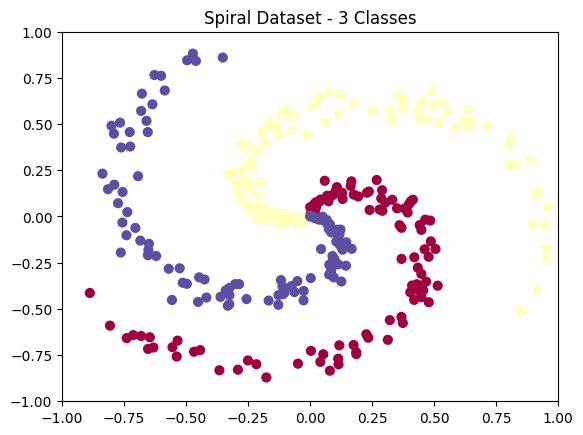

Training data: torch.Size([300, 2])
Training labels: torch.Size([300])
Number of classes: 3


In [119]:
# Generate the same spiral dataset as in the previous notebook
np.random.seed(0)
N = 100  # number of points per class
D = 2    # dimensionality (2D data for visualization)
K = 3    # number of classes
X = np.zeros((N*K, D))  # Data matrix: [300 x 2]
y = np.zeros(N*K, dtype='uint8')  # Class labels: [300]

# Generate spiral data for each class
for j in range(K):
    ix = range(N*j, N*(j+1))  # Indices for current class
    r = np.linspace(0.0, 1, N)  # Radius increases from 0 to 1
    t = np.linspace(j*4, (j+1)*4, N) + np.random.randn(N)*0.2  # Theta angle with noise
    # Convert polar coordinates (r, theta) to Cartesian (x, y)
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]  # np.c_ concatenates columns side-by-side
    y[ix] = j  # Assign class label

# Visualize the dataset
fig = plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim([-1,1])
plt.ylim([-1,1])
plt.title('Spiral Dataset - 3 Classes')
plt.show()

# Convert to PyTorch tensors
X_train = torch.from_numpy(X).float()
y_train = torch.from_numpy(y).long()

print(f"Training data: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Number of classes: {K}")

### Define the Neural Network

Now let's use PyTorch's built-in layers to create our 2-layer network. PyTorch provides `nn.Linear` which handles weights and biases automatically:

In [ ]:
import torch.nn as nn

# Define a 2-layer neural network
class TwoLayerNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TwoLayerNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)   # Layer 1: input -> hidden
        self.fc2 = nn.Linear(hidden_size, output_size)  # Layer 2: hidden -> output

    def forward(self, x):
        # Forward pass through the network
        hidden = torch.relu(self.fc1(x))  # Apply first layer + ReLU
        scores = self.fc2(hidden)         # Apply second layer
        return scores

# Create the model
hidden_size = 100
model = TwoLayerNet(D, hidden_size, K)

print(model)
print(f"\nModel parameters:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape}")

TwoLayerNet(
  (fc1): Linear(in_features=2, out_features=100, bias=True)
  (fc2): Linear(in_features=100, out_features=3, bias=True)
)

Model parameters:
  fc1.weight: torch.Size([100, 2])
  fc1.bias: torch.Size([100])
  fc2.weight: torch.Size([3, 100])
  fc2.bias: torch.Size([3])


### Training Loop

Now training is even cleaner! The model handles the forward pass, and autograd handles the backward pass:

In [121]:
# Create optimizer - it will update all model parameters
optimizer = torch.optim.SGD(model.parameters(), lr=1e-0)

# Hyperparameters
num_iterations = 3000

# Training loop
for i in range(num_iterations):
    # === Forward pass ===
    scores = model(X_train)  # Model handles the forward pass!
    
    # Compute loss
    loss = torch.nn.functional.cross_entropy(scores, y_train)
    
    # === Backward pass ===
    loss.backward()  # Compute gradients automatically
    
    # === Update parameters ===
    optimizer.step()      # Update all parameters
    optimizer.zero_grad() # Zero gradients for next iteration
    
    if i % 50 == 0:
        print(f"Iteration {i}: loss = {loss.item():.4f}")

Iteration 0: loss = 1.1076
Iteration 50: loss = 0.6333
Iteration 100: loss = 0.4216
Iteration 150: loss = 0.3026
Iteration 200: loss = 0.2347
Iteration 250: loss = 0.1935
Iteration 300: loss = 0.1641
Iteration 350: loss = 0.1428
Iteration 400: loss = 0.1269
Iteration 350: loss = 0.1428
Iteration 400: loss = 0.1269
Iteration 450: loss = 0.1146
Iteration 500: loss = 0.1046
Iteration 550: loss = 0.0965
Iteration 600: loss = 0.0898
Iteration 650: loss = 0.0840
Iteration 700: loss = 0.0792
Iteration 450: loss = 0.1146
Iteration 500: loss = 0.1046
Iteration 550: loss = 0.0965
Iteration 600: loss = 0.0898
Iteration 650: loss = 0.0840
Iteration 700: loss = 0.0792
Iteration 750: loss = 0.0750
Iteration 800: loss = 0.0713
Iteration 750: loss = 0.0750
Iteration 800: loss = 0.0713
Iteration 850: loss = 0.0681
Iteration 900: loss = 0.0653
Iteration 950: loss = 0.0627
Iteration 1000: loss = 0.0604
Iteration 1050: loss = 0.0584
Iteration 1100: loss = 0.0565
Iteration 850: loss = 0.0681
Iteration 900:

### Evaluate Training Accuracy

In [122]:
# Compute final accuracy
with torch.no_grad():  # No need to track gradients for evaluation
    scores = model(X_train)
    predicted = torch.argmax(scores, dim=1)
    accuracy = (predicted == y_train).float().mean()
    
print(f"Training accuracy: {accuracy.item():.2%}")

Training accuracy: 99.33%


### Summary: Comparing Manual vs PyTorch Training

Let's compare what we did in the previous notebook vs what we just did:

| Manual (NumPy) | Automatic (PyTorch + nn.Module) |
|----------------|---------------------|
| Manual weight initialization | `nn.Linear` handles initialization |
| `hidden_layer = np.maximum(0, np.dot(X, W) + b)` | `hidden = torch.relu(self.fc1(x))` |
| `scores = np.dot(hidden_layer, W2) + b2` | `scores = self.fc2(hidden)` |
| Manual softmax + cross-entropy | `loss = F.cross_entropy(scores, y_train)` |
| Manual backprop: `grad_W2 = np.dot(...)` | `loss.backward()` ✓ |
| Manual update: `W2 += -step_size * grad_W2` | `optimizer.step()` ✓ |

**Key advantages of PyTorch:**
- **No manual gradient computation** - `.backward()` handles everything
- **`nn.Module`** - Organizes layers and parameters elegantly
- **`nn.Linear`** - Handles weight initialization and forward pass automatically
- **Optimizers** - Handle parameter updates with various algorithms (SGD, Adam, etc.)
- **Less code** - More readable and maintainable
- **Fewer bugs** - No manual gradient calculation errors

We now have everything we need to build and train neural networks efficiently!

---

## How Autograd Works: A Deeper Look

Now let's understand how autograd actually computes these gradients. We'll create two tensors with `requires_grad=True` to track operations.

In [123]:
import torch

a = torch.tensor(2., requires_grad=True)
b = torch.tensor(6., requires_grad=True)

Create a function `Q` from `a` and `b`:

$$Q = 3a^3 - b^2$$

In [124]:
Q = 3*a**3 - b**2

In [125]:
print(f"Q = {Q}")

Q = -12.0


### Understanding Gradients: The Connection to Calculus

Think of `a` and `b` as parameters (like our `W` and `b` from the previous notebook) and `Q` as a loss function.

**What are gradients?** In neural networks, **gradients are simply derivatives** (or partial derivatives for multivariable functions). They tell us how much the output changes when we make a small change to the input.

From calculus, we know:
- The derivative $\frac{dQ}{da}$ tells us the **rate of change** of $Q$ with respect to $a$
- If $\frac{dQ}{da} > 0$, increasing $a$ will increase $Q$
- If $\frac{dQ}{da} < 0$, increasing $a$ will decrease $Q$

For our function $Q = 3a^3 - b^2$, we can compute the derivatives using standard calculus rules:

$$\frac{\partial Q}{\partial a} = 9a^2$$

$$\frac{\partial Q}{\partial b} = -2b$$

In machine learning, we use these derivatives (gradients) to **update our parameters in the direction that reduces the loss**. If the gradient is positive, we decrease the parameter; if negative, we increase it. This is the essence of gradient descent!

When we call `.backward()` on `Q`, autograd automatically calculates these derivatives using the chain rule (just like we did manually in the previous notebook!) and stores them in the `.grad` attribute.

Since `Q` is a scalar (single value), we can simply call `.backward()` without any arguments:

In [126]:
# Compute gradients
Q.backward()

Check that the computed gradients match the mathematical derivatives:

In [127]:
# Verify gradients are correct
print(f"a.grad = {a.grad}")
print(f"Expected (9*a^2) = {9*a**2}")
print(f"Match: {torch.allclose(9*a**2, a.grad)}\n")

print(f"b.grad = {b.grad}")
print(f"Expected (-2*b) = {-2*b}")
print(f"Match: {torch.allclose(-2*b, b.grad)}")

a.grad = 36.0
Expected (9*a^2) = 36.0
Match: True

b.grad = -12.0
Expected (-2*b) = -12.0
Match: True


---

## Summary

We've now learned how PyTorch's autograd works! Here's what we covered:

### Key Concepts

1. **Automatic Differentiation**: PyTorch automatically computes gradients using the chain rule (backpropagation)
   - Set `requires_grad=True` on tensors we want gradients for
   - Call `.backward()` to compute all gradients
   - Access gradients via `.grad` attribute

2. **Computational Graph**: PyTorch builds a graph of operations during the forward pass, then traverses it backward to compute gradients

3. **nn.Module and nn.Linear**: Organize neural networks with proper classes
   - `nn.Linear` handles weight initialization and forward pass
   - `nn.Module` provides structure for organizing layers and parameters
   - `model.parameters()` gives us all trainable parameters

4. **Training Workflow**:
   ```python
   # Forward pass
   scores = model(X_train)
   loss = loss_function(scores, y_train)
   
   # Backward pass (compute gradients)
   loss.backward()
   
   # Update parameters
   optimizer.step()
   optimizer.zero_grad()
   ```

5. **Gradient Control**: 
   - Use `requires_grad=False` to freeze parameters we don't want to update
   - Use `torch.no_grad()` for evaluation when we don't need gradients at all

### Connecting to What We Learned

In the previous notebook, we manually computed gradients like this:
```python
grad_scores = probs.copy()
grad_scores[range(num_examples), y] -= 1
grad_W2 = np.dot(hidden_layer.T, grad_scores)
```

Now we know that PyTorch does all of this automatically when we call `loss.backward()`!

### What's Next?

Now that we understand autograd and nn.Module, we're ready to:
- Build more complex neural networks with multiple layers
- Use pre-built layers, activation functions, and loss functions
- Train on GPUs for faster computation
- Experiment with different architectures without worrying about gradients
- Apply transfer learning by freezing/unfreezing layers

The power of autograd is that we can focus on designing our model, and PyTorch handles all the gradient computations for us!